In [ ]:
# TAD boundary calling on chr13 using insulation + CTCF enrichment

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cooler
import cooltools
from cooltools import insulation
import cooltools.lib.plotting

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.4'):
    raise AssertionError(
        "This notebook requires cooltools >= 0.5.4; please update cooltools."
    )

from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import bioframe
import bbi

plt.rcParams['font.size'] = 12

# -----------------------------
# Paths and basic parameters
# -----------------------------

base_dir = "/media/ggj/ggj/CJY/nature_WXY/Hi-c/file"

wt_cool = f"{base_dir}/WT/cool_file/WT_merged_main_1kb_30bin.cool"
ko_cool = f"{base_dir}/KO/cool_file/KO_merged_main_1kb_30bin.cool"

wt_ctcf_bigwig = f"/media/ggj/ggj/CJY/cuttag/bulkCUT/bw/CTCF/WT/Heart.CTCF.bin10.bw"  
ko_ctcf_bigwig = f"/media/ggj/ggj/CJY/cuttag/bulkCUT/bw/CTCF/KO/Heart.CTCF.bin10.bw"  

wt_ctcf_bed = f"/media/ggj/ggj/CJY/cuttag/bulkCUT/peak_shuf/WT/CTCF/Heart/Heart_peaks_20.narrowPeak" 

resolution = 30_000
windows = [3 * resolution, 5 * resolution, 10 * resolution, 25 * resolution]
main_window = windows[0]  

clr_wt = cooler.Cooler(wt_cool)


In [3]:
# Functions to help with plotting
def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, *args, **kwargs):
    start_pos_vector = [start + resolution * i for i in range(len(matrix_c) + 1)]
    import itertools
    n = matrix_c.shape[0]
    t = np.array([[1, 0.5], [-1, 0.5]])
    matrix_a = np.dot(
        np.array([
            (i[1], i[0])
            for i in itertools.product(start_pos_vector[::-1], start_pos_vector)
        ]),
        t,
    )
    x = matrix_a[:, 1].reshape(n + 1, n + 1)
    y = matrix_a[:, 0].reshape(n + 1, n + 1)
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), *args, **kwargs)
    im.set_rasterized(True)
    return im

In [ ]:
# Compute insulation on chr13 for WT

if resolution != 30_000:
    raise ValueError("Resolution in this notebook is expected to be 30 kb.")

insulation_table_wt = insulation(clr_wt, windows, verbose=True)

insul_chr13_wt = insulation_table_wt[insulation_table_wt["chrom"] == "chr13"].copy()
insul_chr13_wt.reset_index(drop=False, inplace=True) 
insul_chr13_wt.rename(columns={"index": "orig_index"}, inplace=True)

insul_chr13_wt.head()

INFO:root:fallback to serial implementation.
INFO:root:Processing region chr1
INFO:root:Processing region chr10
INFO:root:Processing region chr11
INFO:root:Processing region chr12
INFO:root:Processing region chr13
INFO:root:Processing region chr14
INFO:root:Processing region chr15
INFO:root:Processing region chr16
INFO:root:Processing region chr17
INFO:root:Processing region chr18
INFO:root:Processing region chr19
INFO:root:Processing region chr2
INFO:root:Processing region chr3
INFO:root:Processing region chr4
INFO:root:Processing region chr5
INFO:root:Processing region chr6
INFO:root:Processing region chr7
INFO:root:Processing region chr8
INFO:root:Processing region chr9
INFO:root:Processing region chrX
INFO:root:Processing region chrY


,orig_index,chrom,start,end,region,is_bad_bin,log2_insulation_score_90000,n_valid_pixels_90000,log2_insulation_score_150000,n_valid_pixels_150000,...,log2_insulation_score_750000,n_valid_pixels_750000,boundary_strength_90000,boundary_strength_150000,boundary_strength_300000,boundary_strength_750000,is_boundary_90000,is_boundary_150000,is_boundary_300000,is_boundary_750000
0,18948,chr13,0,30000,chr13,True,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,NaN,NaN,NaN,False,False,False,False
1,18949,chr13,30000,60000,chr13,True,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,NaN,NaN,NaN,False,False,False,False
2,18950,chr13,60000,90000,chr13,True,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,NaN,NaN,NaN,False,False,False,False
3,18951,chr13,90000,120000,chr13,True,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,NaN,NaN,NaN,False,False,False,False
4,18952,chr13,120000,150000,chr13,True,NaN,0.0,NaN,0.0,...,NaN,0.0,NaN,NaN,NaN,NaN,False,False,False,False


In [ ]:
# Select strong insulation boundaries on chr13 based on cooltools' is_boundary column
bs_col = f"boundary_strength_{main_window}"
is_boundary_col = f"is_boundary_{main_window}"

boundaries_chr13 = insul_chr13_wt[~insul_chr13_wt[bs_col].isna()].copy()

strong_boundaries_chr13 = boundaries_chr13[boundaries_chr13[is_boundary_col]].copy()

print(f"Total chr13 bins: {len(insul_chr13_wt)}")
print(f"Candidate boundaries on chr13 (non-NaN {bs_col}): {len(boundaries_chr13)}")
print(f"Strong boundaries on chr13 (cooltools {is_boundary_col}): {len(strong_boundaries_chr13)}")

strong_boundaries_chr13.head()

Total chr13 bins: 4015
Candidate boundaries on chr13 (non-NaN boundary_strength_90000): 729
Strong boundaries on chr13 (cooltools is_boundary_90000): 234


,orig_index,chrom,start,end,region,is_bad_bin,log2_insulation_score_90000,n_valid_pixels_90000,log2_insulation_score_150000,n_valid_pixels_150000,...,log2_insulation_score_750000,n_valid_pixels_750000,boundary_strength_90000,boundary_strength_150000,boundary_strength_300000,boundary_strength_750000,is_boundary_90000,is_boundary_150000,is_boundary_300000,is_boundary_750000
112,19060,chr13,3360000,3390000,chr13,False,-1.357049,6.0,-1.357135,22.0,...,-0.747054,322.0,2.368381,2.485968,2.662315,NaN,True,True,True,False
121,19069,chr13,3630000,3660000,chr13,False,-0.696569,6.0,-0.554380,22.0,...,-0.129851,547.0,1.100015,1.030033,NaN,NaN,True,True,False,False
130,19078,chr13,3900000,3930000,chr13,False,-0.531320,6.0,-0.428044,22.0,...,-0.197660,622.0,1.256628,NaN,NaN,NaN,True,False,False,False
144,19092,chr13,4320000,4350000,chr13,False,-0.589461,6.0,-0.614438,22.0,...,-0.669007,622.0,0.607997,0.592692,0.057748,0.030665,True,True,False,False
154,19102,chr13,4620000,4650000,chr13,False,-1.037909,6.0,-1.098679,22.0,...,-0.930093,622.0,1.779551,2.219995,NaN,NaN,True,True,False,False


In [ ]:
# Use CTCF bigWig to select CTCF-enriched strong boundaries on chr13

flank_bp = 1_500  
ctcf_signal_chr13 = bbi.stackup(
    wt_ctcf_bigwig,
    strong_boundaries_chr13["chrom"].values,
    strong_boundaries_chr13["start"].values - flank_bp,
    strong_boundaries_chr13["end"].values + flank_bp,
    bins=1,
).flatten()

strong_boundaries_chr13["ctcf_signal"] = ctcf_signal_chr13

ctcf_sig_threshold = np.nanmedian(strong_boundaries_chr13["ctcf_signal"].values)

ctcf_strong_boundaries_chr13 = strong_boundaries_chr13[
    strong_boundaries_chr13["ctcf_signal"] >= ctcf_sig_threshold
].copy()

print(
    f"CTCF-enriched strong boundaries on chr13 "
    f"(signal ≥ median = {ctcf_sig_threshold:.3f}): "
    f"{len(ctcf_strong_boundaries_chr13)}"
)

ctcf_strong_boundaries_chr13.head()

CTCF-enriched strong boundaries on chr13 (signal ≥ median = 0.069): 117


,orig_index,chrom,start,end,region,is_bad_bin,log2_insulation_score_90000,n_valid_pixels_90000,log2_insulation_score_150000,n_valid_pixels_150000,...,boundary_strength_90000,boundary_strength_150000,boundary_strength_300000,boundary_strength_750000,is_boundary_90000,is_boundary_150000,is_boundary_300000,is_boundary_750000,ctcf_chip_fc,ctcf_signal
112,19060,chr13,3360000,3390000,chr13,False,-1.357049,6.0,-1.357135,22.0,...,2.368381,2.485968,2.662315,NaN,True,True,True,False,0.070363,0.070363
217,19165,chr13,6510000,6540000,chr13,False,-0.749418,6.0,-1.058463,22.0,...,0.830960,1.132219,NaN,NaN,True,True,False,False,0.081450,0.081450
328,19276,chr13,9840000,9870000,chr13,False,-1.045211,6.0,-1.172150,22.0,...,1.538869,1.643561,NaN,1.013466,True,True,False,True,0.117413,0.117413
449,19397,chr13,13470000,13500000,chr13,False,-0.275507,6.0,-0.167105,17.0,...,0.604049,NaN,NaN,NaN,True,False,False,False,0.072022,0.072022
462,19410,chr13,13860000,13890000,chr13,False,-0.540161,6.0,-0.670584,22.0,...,1.307177,1.320404,NaN,NaN,True,True,False,False,0.072444,0.072444


In [ ]:
# Map CTCF-enriched strong boundaries back to the full insulation table (WT)

ctcf_boundary_col = f"is_boundary_{main_window}_ctcf"

insulation_table_wt[ctcf_boundary_col] = False

insulation_table_wt.loc[ctcf_strong_boundaries_chr13["orig_index"].values, ctcf_boundary_col] = True

print(insulation_table_wt[["chrom", "start", "end", is_boundary_col, ctcf_boundary_col]].query("chrom == 'chr13'").head())

       chrom   start     end  is_boundary_90000  is_boundary_90000_ctcf
18948  chr13       0   30000              False                   False
18949  chr13   30000   60000              False                   False
18950  chr13   60000   90000              False                   False
18951  chr13   90000  120000              False                   False
18952  chr13  120000  150000              False                   False


In [ ]:
# Extract TADs on chr13 using the CTCF-enriched strong boundaries

def extract_TADs(insulation_table, boundary_col, chrom="chr13", max_TAD_length=3_000_000):
    """Extract inter-boundary intervals (TADs) on a given chromosome.

    TADs are defined as merged stretches of bins where `boundary_col == False`.
    """
    mask = (insulation_table["chrom"] == chrom) & (~insulation_table[boundary_col])
    intervals = insulation_table.loc[mask, ["chrom", "start", "end"]]

    tads = bioframe.merge(intervals)

    tads = tads[(tads["end"] - tads["start"]) <= max_TAD_length]

    return tads.reset_index(drop=True)[["chrom", "start", "end"]]

TADs_chr13_wt = extract_TADs(insulation_table_wt, ctcf_boundary_col, chrom="chr13")
print(f"Number of TADs on chr13 (WT, CTCF-enriched boundaries): {len(TADs_chr13_wt)}")
TADs_chr13_wt.head()

Number of TADs on chr13 (WT, CTCF-enriched boundaries): 107


,chrom,start,end
0,chr13,13500000,13860000
1,chr13,17700000,17820000
2,chr13,17850000,20280000
3,chr13,20310000,21690000
4,chr13,21720000,22050000


In [ ]:
# CTCF boundary
summary_rows = []

for w in windows:
    bs_col_w = f"boundary_strength_{w}"
    isb_col_w = f"is_boundary_{w}"

    sub = insulation_table_wt[insulation_table_wt["chrom"] == "chr13"].copy()
    cand = sub[~sub[bs_col_w].isna()]
    strong = cand[cand[isb_col_w]]

    if w == main_window:
        ctcf_col_w = f"is_boundary_{w}_ctcf"
        ctcf_strong = sub[sub[ctcf_col_w]]
        n_ctcf_strong = len(ctcf_strong)
    else:
        ctcf_col_w = None
        n_ctcf_strong = np.nan

    summary_rows.append(
        dict(
            window_bp=w,
            window_kb=w // 1000,
            n_bins_chr13=len(sub),
            n_candidate_boundaries=len(cand),
            n_strong_boundaries=len(strong),
            n_ctcf_enriched_strong_boundaries=n_ctcf_strong,
        )
    )

boundary_summary_chr13 = pd.DataFrame(summary_rows)
boundary_summary_chr13

,window_bp,window_kb,n_bins_chr13,n_candidate_boundaries,n_strong_boundaries,n_ctcf_enriched_strong_boundaries
0,90000,90,4015,729,234,117.0
1,150000,150,4015,496,205,NaN
2,300000,300,4015,362,151,NaN
3,750000,750,4015,261,92,NaN


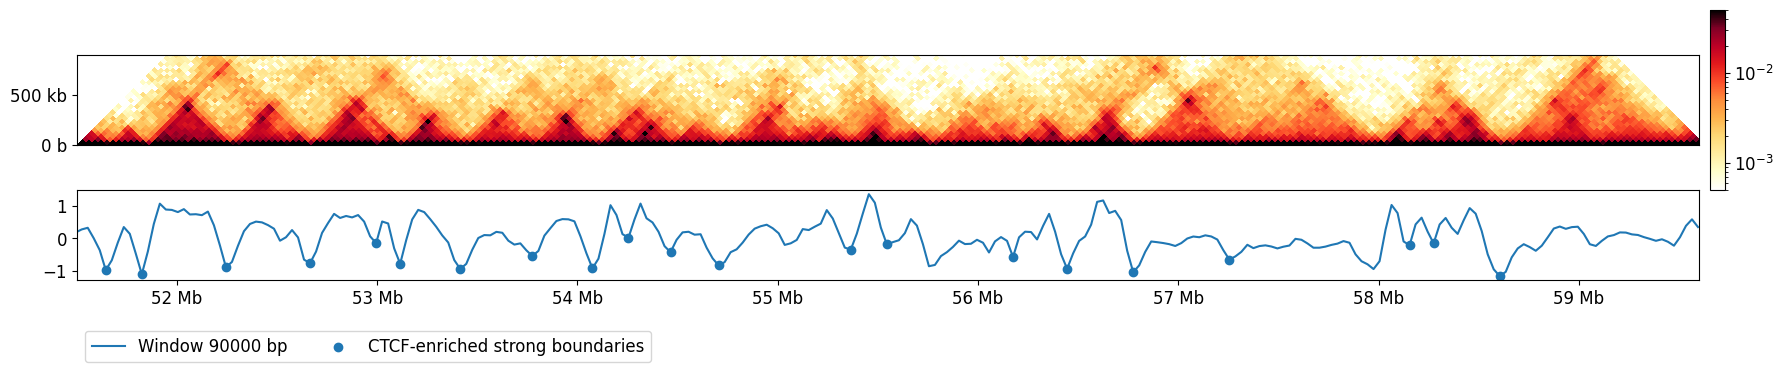

In [ ]:
# Visualization on chr13: same region as in the original WT insulation notebook

# from cooltools.lib.plotting import pcolormesh_45deg
from matplotlib.ticker import EngFormatter

bp_formatter = EngFormatter('b')


def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        for label in ax.get_xticklabels():
            label.set_rotation(90 if rotate else 0)

start = 51_500_000
end = start + 90 * main_window
region = ("chr13", start, end)

norm = LogNorm(vmax=0.05, vmin=0.0005)

data_wt = clr_wt.matrix(balance=True).fetch(region)

f, ax = plt.subplots(figsize=(18, 6))
im = pcolormesh_45deg(
    ax,
    data_wt,
    start=region[1],
    resolution=resolution,
    norm=norm,
    cmap="fall",
)
ax.set_aspect(0.5)
ax.set_ylim(0, 10 * main_window)
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = bioframe.select(insulation_table_wt, region)

ins_ax = divider.append_axes("bottom", size="50%", pad=0.0, sharex=ax)

ins_ax.plot(
    insul_region[["start", "end"]].mean(axis=1),
    insul_region[f"log2_insulation_score_{main_window}"],
    label=f"Window {main_window} bp",
)

ctcf_bound_region = insul_region[insul_region[ctcf_boundary_col]].copy()

ins_ax.scatter(
    ctcf_bound_region[["start", "end"]].mean(axis=1),
    ctcf_bound_region[f"log2_insulation_score_{main_window}"],
    label="CTCF-enriched strong boundaries",
)

ins_ax.legend(bbox_to_anchor=(0.0, -1.0), loc="lower left", ncol=2)

format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])

plt.tight_layout()
plt.show()

In [ ]:
# TAD boundary calling on chr13 using insulation + CTCF enrichment

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cooler
import cooltools
from cooltools import insulation
import cooltools.lib.plotting

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.4'):
    raise AssertionError(
        "This notebook requires cooltools >= 0.5.4; please update cooltools."
    )

from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import bioframe
import bbi

plt.rcParams['font.size'] = 12

# -----------------------------
# Paths and basic parameters
# -----------------------------

base_dir = "/media/ggj/ggj/CJY/nature_WXY/Hi-c/file"

wt_cool = f"{base_dir}/WT/cool_file/WT_merged_main_1kb_30bin.cool"
ko_cool = f"{base_dir}/KO/cool_file/KO_merged_main_1kb_30bin.cool"

wt_ctcf_bigwig = f"{base_dir}/WT/CTCF_WT.bigWig"  
ko_ctcf_bigwig = f"{base_dir}/KO/CTCF_KO.bigWig" 

wt_ctcf_bed = f"{base_dir}/WT/CTCF_WT_peaks.bed"  

resolution = 30_000
windows = [3 * resolution, 5 * resolution, 10 * resolution, 25 * resolution]
main_window = windows[0] 
clr_wt = cooler.Cooler(wt_cool)
